# Detecção de Bots: Análise e Modelagem

Case técnico Incognia. Este notebook percorre todo o caminho analítico: composição
do dataset, análise exploratória, os cinco experimentos definidos no plano de
pesquisa, e a exportação do modelo treinado para o navegador.

A engenharia de features **não** acontece aqui. Ela vive em `web/src/features.js` e
roda tanto no navegador quanto sob Node, o que elimina divergência entre treino e
inferência por construção. Este notebook consome a matriz já extraída:

```bash
node analysis/scripts/extract_features.js
```

Para executar tudo sem abrir a interface:

```bash
.venv/bin/jupyter nbconvert --to notebook --execute --inplace \
  analysis/notebooks/bot_detection_analysis.ipynb


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
while not (ROOT / "web" / "src" / "features.js").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RNG = np.random.default_rng(20260912)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

print("raiz do projeto:", ROOT)

# Superfície clara fixa: um PNG não se adapta ao tema do GitHub, e claro sobre
# escuro lê melhor que o contrário.
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
# Paleta categórica validada (ΔE CVD 9.2, visão normal 24.0 no pior par).
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"


def eixo(ax, titulo, grid="y"):
    ax.set_facecolor(SURFACE)
    ax.grid(axis=grid, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
    ax.set_title(titulo, color=INK, fontsize=12, loc="left", pad=10)


def mostrar(fig):
    """As figuras vivem no notebook, não em arquivo: quem quiser o número exato
    tem a tabela da seção correspondente, e o relatório não depende de binário."""
    fig.patch.set_facecolor(SURFACE)
    fig.tight_layout()
    plt.show()


pct = lambda v, _: f"{v:.0%}"


raiz do projeto: /home/leandro/Documentos/browser-bot-detection


## 1. Carregamento

Colunas constantes são descartadas e o descarte é reportado. Uma feature que nunca
varia não carrega informação e só polui a análise de importância.

In [2]:
LAYER_PREFIX = {
    "a_": "A (automação)",
    "e_": "B (ambiente)",
    "t_": "C (timing)",
    "b_": "D (comportamento)",
}

# Espelha META_COLS de analysis/scripts/extract_features.js. Uma coluna de meta
# que falte aqui vira feature, e o primeiro teste que tocar nela quebra.
META_COLS = ["session_id", "label", "tool", "config", "journey", "evasion",
             "headless", "participant", "viewport", "locale", "timezone",
             "n_events", "elapsed_ms", "baseline_prob", "baseline_score",
             "baseline_rules_fired", "baseline_rules", "cut_ms"]


def layer_of(name: str) -> str:
    for prefix, label in LAYER_PREFIX.items():
        if name.startswith(prefix):
            return label
    return "outro"


df = pd.read_csv(ROOT / "data/features/features.csv", low_memory=False)

# Só entram pessoas com código de participante atribuído (P01, P02...). A sessão
# gravada com o código que o navegador sorteia é anterior ao protocolo de códigos,
# não tem jornada declarada e não descreve o roteiro que as outras seguiram.
sem_codigo = (df.label == "human") & ~df.participant.fillna("").str.fullmatch(r"P\d+")
if sem_codigo.any():
    print(f"{int(sem_codigo.sum())} sessões humanas sem código atribuído, removidas: "
          f"{sorted(df.loc[sem_codigo, 'participant'].unique())}")
    df = df[~sem_codigo].reset_index(drop=True)
feats = [c for c in df.columns if c not in META_COLS]

# Features que descrevem o caminho de rede, não o visitante. Sessões automatizadas
# e humanas não vêm pelo mesmo caminho nem quando a URL é a mesma, e um modelo que
# aprende "resposta em 2ms" aprendeu onde a sessão foi gravada, não quem a gravou.
ROUTE_LEAKAGE = ["t_nav_response", "t_nav_dom_interactive", "t_first_paint",
                 "e_conn_rtt", "e_history_length", "e_referrer_present"]
leaked = [c for c in feats if c in ROUTE_LEAKAGE]
feats = [c for c in feats if c not in ROUTE_LEAKAGE]

# Features que descrevem o protocolo de coleta, e não o visitante. A pessoa decide
# quando clicar em enviar; o bot é gravado ao fim de um roteiro de duração fixa. A
# duração, o tempo até o primeiro evento e toda contagem bruta, que cresce com a
# duração, separariam as classes pelo protocolo. Taxas e razões ficam.
PROTOCOL_LEAKAGE = [c for c in feats
                    if c in ("b_duration_ms", "b_time_to_first_event")
                    or (c.startswith("b_") and c.endswith("_count"))]
leaked += PROTOCOL_LEAKAGE
feats = [c for c in feats if c not in PROTOCOL_LEAKAGE]

# O salto de rolagem mede o passo do aparelho, não a pessoa: quantos pixels a
# página anda por entalhe da roda, por toque ou por tecla. Ele separa as classes
# deste conjunto sem sobreposição, e um modelo treinado com ele vira um corte só
# nessa medida, que chama de bot quem rola pelo teclado ou com a roda sem rolagem
# suave. Fica fora do treino pelo mesmo motivo das features de caminho de rede.
DEVICE_LEAKAGE = [c for c in feats if c.startswith("b_scroll_jump")]
leaked += DEVICE_LEAKAGE
feats = [c for c in feats if c not in DEVICE_LEAKAGE]

nunique = df[feats].nunique(dropna=True)
constant = [c for c in feats if nunique.get(c, 0) <= 1]
feats = [c for c in feats if c not in constant]

print(f"{len(df)} sessões, {len(feats)} features não constantes "
      f"({len(constant)} constantes e {len(leaked)} de caminho de rede ou de protocolo descartadas)")
print("\nfeatures por camada:")


1 sessões humanas sem código atribuído, removidas: ['p_mk19vj8e']
211 sessões, 185 features não constantes (34 constantes e 40 de caminho de rede ou de protocolo descartadas)

features por camada:


## 2. Composição do Dataset

Antes de qualquer modelo, vale olhar de onde os dados vêm. O eixo que mais importa
é a sofisticação do adversário: sem evasão, configurações headless carregam sinais
de ambiente tão fortes que qualquer detector as separa com folga, e medir só contra


In [3]:
print("por rótulo:")
print(df.label.value_counts().to_string())

print("\npor configuração e jornada:")
print(df.groupby(["config", "journey"], dropna=False).size().to_string())

if "participant" in df:
    print(f"\nparticipantes/grupos distintos: {df.participant.nunique()}")

por rótulo:
label
bot      180
human     31

por configuração e jornada:
config                        journey  
pw-chromium-headful           humanized     6
                              idle          6
                              naive         6
pw-chromium-headful-evasion   humanized     6
                              idle          6
                              naive         6
pw-chromium-headful-flag      humanized     6
                              idle          6
                              naive         6
pw-chromium-headless          humanized     6
                              idle          6
                              naive         7
pw-chromium-headless-evasion  humanized     6
                              idle          6
                              naive         6
pw-chromium-shell             humanized     6
                              idle          6
                              naive         6
pw-firefox-headful            humanized     6
             

## 2b. O Motor de Regras contra a Matriz

Antes de qualquer modelo, o que a página **realmente executa**. Esta tabela funciona
com uma classe só: para sessões `bot` a coluna é taxa de detecção, para `human` é
taxa de falso positivo. É a métrica que responde ao enunciado, e a única disponível


In [4]:
# O limiar vive em web/src/baseline.js (THRESHOLD) e é replicado aqui, não redefinido:
# mudar um sem o outro faria esta tabela descrever uma página que não existe.
BASELINE_THRESHOLD = 0.5

flagged = df.baseline_prob >= BASELINE_THRESHOLD
baseline_tbl = (df.assign(sinalizado=flagged)
                .groupby(["label", "config", "journey"], dropna=False)
                .agg(n=("sinalizado", "size"),
                     taxa=("sinalizado", "mean"),
                     p_mediana=("baseline_prob", "median"),
                     p_min=("baseline_prob", "min"))
                .reset_index()
                .sort_values(["label", "config", "journey"]))
display(baseline_tbl.round(4))

for label, g in df.groupby("label"):
    rate = (g.baseline_prob >= BASELINE_THRESHOLD).mean()
    kind = "detecção" if label == "bot" else "falso positivo"
    print(f"{label}: {len(g)} sessões, taxa de {kind} {rate:.1%}")

/tmp/ipykernel_11101/3918351858.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baseline_tbl = (df.assign(sinalizado=flagged)


,label,config,journey,n,taxa,p_mediana,p_min
0,bot,pw-chromium-headful,humanized,6,1.0,0.9500,0.9500
1,bot,pw-chromium-headful,idle,6,1.0,0.9500,0.9500
2,bot,pw-chromium-headful,naive,6,1.0,0.9553,0.9505
3,bot,pw-chromium-headful-evasion,humanized,6,1.0,0.9066,0.9066
4,bot,pw-chromium-headful-evasion,idle,6,1.0,0.9066,0.9066
5,bot,pw-chromium-headful-evasion,naive,6,1.0,0.9933,0.9933
6,bot,pw-chromium-headful-flag,humanized,6,0.0,0.1865,0.1693
7,bot,pw-chromium-headful-flag,idle,6,0.0,0.1865,0.1693
8,bot,pw-chromium-headful-flag,naive,6,1.0,0.7570,0.7570
9,bot,pw-chromium-headless,humanized,6,1.0,0.9641,0.9601


bot: 180 sessões, taxa de detecção 80.6%
human: 31 sessões, taxa de falso positivo 0.0%


In [5]:
# Ausência por feature. Metade do conjunto é legitimamente ausente em sessões
# curtas: features comportamentais só existem quando houve interação.
miss = df[feats].isna().mean().sort_values(ascending=False)
print(f"ausência média: {miss.mean():.1%}")
print(f"features ausentes em mais de metade das sessões: {(miss > 0.5).sum()}")

miss_by_layer = (pd.DataFrame({"feature": feats, "miss": [miss[f] for f in feats]})
                 .assign(camada=lambda d: d.feature.map(layer_of))
                 .groupby("camada")["miss"].mean().sort_values())
print("\nausência média por camada:")
print(miss_by_layer.to_string())

ausência média: 36.1%
features ausentes em mais de metade das sessões: 97

ausência média por camada:
camada
C (timing)           0.000000
B (ambiente)         0.005621
A (automação)        0.016803
D (comportamento)    0.572111


## 3. Testes Distributivos

Kolmogorov-Smirnov por feature entre as duas classes, com correção de
Benjamini-Hochberg. A correção não é formalidade: testar cerca de 260 features a


In [6]:
def ks_table(df: pd.DataFrame, feats: list[str], alpha: float = 0.05) -> pd.DataFrame:
    human = df[df.label == "human"]
    bot = df[df.label == "bot"]
    rows = []
    for f in feats:
        a = human[f].dropna().to_numpy()
        b = bot[f].dropna().to_numpy()
        if len(a) < 8 or len(b) < 8:
            continue
        try:
            ks, p = stats.ks_2samp(a, b)
        except ValueError:
            continue
        rows.append((f, layer_of(f), ks, p))

    out = (pd.DataFrame(rows, columns=["feature", "camada", "ks", "p"])
           .sort_values("p").reset_index(drop=True))
    if out.empty:
        return out.assign(significativo=pd.Series(dtype=bool))
    m = len(out)
    out["rank"] = np.arange(1, m + 1)
    out["bh"] = alpha * out["rank"] / m
    # BH é procedimento de corte: tudo até o maior índice que passa é significativo.
    passing = out.index[out.p <= out.bh]
    cutoff = passing.max() if len(passing) else -1
    out["significativo"] = out.index <= cutoff
    return out


if df.label.nunique() >= 2:
    ks = ks_table(df, feats)
    print(f"{int(ks.significativo.sum())} de {len(ks)} features separam as classes "
          f"com significância após correção BH")
    display(ks.sort_values("ks", ascending=False).head(20)[["feature", "camada", "ks", "p"]])
else:
    ks = pd.DataFrame()
    print(f"dataset contém apenas a classe '{df.label.iloc[0]}'; teste indisponível")

118 de 185 features separam as classes com significância após correção BH


,feature,camada,ks,p
4,b_pm_turn_mean,D (comportamento),1.000000,1.846712e-16
8,b_wheel_delta_unique_ratio,D (comportamento),1.000000,8.771881e-16
7,b_pm_reversal_rate,D (comportamento),1.000000,1.846712e-16
6,b_pm_turn_std,D (comportamento),1.000000,1.846712e-16
5,b_pm_turn_p95,D (comportamento),1.000000,1.846712e-16
12,b_pm_turn_p50,D (comportamento),0.937500,1.894726e-13
14,b_pm_accel_cv,D (comportamento),0.920833,1.060197e-12
0,b_click_dwell_mean,D (comportamento),0.917355,1.360667e-23
1,b_click_dwell_p50,D (comportamento),0.909091,5.527858e-23
2,b_click_dwell_max,D (comportamento),0.903226,5.528142e-23


## 4. Métricas e Protocolo de Avaliação

Três decisões metodológicas, cada uma com um motivo específico.

**Ponto de operação em TPR @ FPR = 1%, não acurácia.** Em prevenção a fraude o
custo de um falso positivo, que é atrito imposto a um usuário legítimo, é
assimétrico em relação ao de um falso negativo. Acurácia trata os dois como
equivalentes e por isso responde a pergunta errada.

**Particionamento agrupado por participante.** Sem isso, sessões da mesma pessoa
caem nos dois lados da divisão e a métrica passa a medir memorização daquela
pessoa em vez de generalização. É o erro mais comum em biometria comportamental, e
o mais difícil de notar, porque ele só faz o número melhorar.

**Intervalos por bootstrap.** Com poucas dezenas de participantes, uma métrica


In [7]:
def tpr_at_fpr(y, p, target_fpr: float = 0.01) -> float:
    """Taxa de detecção no orçamento de falso positivo que o produto aceita."""
    if len(np.unique(y)) < 2:
        return float("nan")
    fpr, tpr, _ = roc_curve(y, p)
    ok = fpr <= target_fpr
    return float(tpr[ok].max()) if ok.any() else 0.0


def bootstrap_ci(y, p, fn, groups=None, n: int = 2000, alpha: float = 0.05):
    """Reamostra participantes, não sessões: sessões da mesma pessoa não são
    independentes, e reamostrá-las uma a uma estreitaria o intervalo."""
    y, p = np.asarray(y), np.asarray(p)
    groups = np.arange(len(y)) if groups is None else np.asarray(groups)
    members = [np.flatnonzero(groups == g) for g in np.unique(groups)]
    vals = []
    for _ in range(n):
        picked = RNG.integers(0, len(members), len(members))
        idx = np.concatenate([members[i] for i in picked])
        if len(np.unique(y[idx])) < 2:
            continue
        try:
            vals.append(fn(y[idx], p[idx]))
        except ValueError:
            continue
    if not vals:
        return (float("nan"), float("nan"))
    return (float(np.percentile(vals, 100 * alpha / 2)),
            float(np.percentile(vals, 100 * (1 - alpha / 2))))


def summarize(y, p, threshold: float = 0.5, ci: bool = True, groups=None) -> dict:
    yhat = (np.asarray(p) >= threshold).astype(int)
    out = {
        "n": int(len(y)),
        "roc_auc": float(roc_auc_score(y, p)) if len(np.unique(y)) > 1 else float("nan"),
        "pr_auc": float(average_precision_score(y, p)) if len(np.unique(y)) > 1 else float("nan"),
        "tpr@1%fpr": tpr_at_fpr(y, p),
        "precision": float(precision_score(y, yhat, zero_division=0)),
        "recall": float(recall_score(y, yhat, zero_division=0)),
        "f1": float(f1_score(y, yhat, zero_division=0)),
    }
    if ci:
        lo, hi = bootstrap_ci(y, p, roc_auc_score, groups)
        out["auc_lo"], out["auc_hi"] = lo, hi
        lo, hi = bootstrap_ci(y, p, tpr_at_fpr, groups)
        out["tpr_lo"], out["tpr_hi"] = lo, hi
    return out

### Famílias de Modelo

A regressão logística entra como referência interpretável na comparação, não como
candidata a ir para a página: com ela dá para ler o peso de cada feature direto.

O gradient boosting consome `NaN` nativamente, aprendendo por nó para que lado
mandar um valor ausente. Isso importa porque metade das features deste problema é
legitimamente ausente em sessões curtas, e imputar apagaria a informação de que a
ausência em si carrega significado. É o que vai para o navegador, se vencer as regras.

Os sinais listados na página vêm do motor de regras. Quando o modelo decide,


In [8]:
def make_logistic() -> Pipeline:
    return Pipeline([
        # add_indicator preserva o fato de o valor estar ausente, que é sinal
        # próprio: uma sessão sem interação não é o mesmo que interação de valor zero.
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=0.5,
                                   class_weight="balanced", max_iter=5000)),
    ])


def make_gbdt() -> HistGradientBoostingClassifier:
    return HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15,
        min_samples_leaf=8, l2_regularization=1.0,
        class_weight="balanced", random_state=42,
    )


def cv_predict(model_fn, X: pd.DataFrame, y: np.ndarray, groups: np.ndarray,
               n_splits: int = 5) -> np.ndarray:
    """Predição fora da amostra, com grupos preservados entre as partições."""
    n_splits = max(2, min(n_splits, len(np.unique(groups))))
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.full(len(y), np.nan)
    for tr, te in cv.split(X, y, groups):
        if len(np.unique(y[tr])) < 2:
            continue
        model = model_fn()
        model.fit(X.iloc[tr], y[tr])
        oof[te] = model.predict_proba(X.iloc[te])[:, 1]
    return oof


HAS_BOTH_CLASSES = df.label.nunique() >= 2
if HAS_BOTH_CLASSES:
    y = (df.label == "bot").astype(int).to_numpy()
    groups = df.participant.fillna("desconhecido").to_numpy()
    print(f"pronto para modelar: {y.sum()} bots, {(1 - y).sum()} humanos, "
          f"{len(np.unique(groups))} grupos")
    # Com N sessões humanas, o menor FPR acima de zero é 1/N. Abaixo de 100 sessões,
    # "TPR @ 1% FPR" é, na prática, a detecção sem nenhum falso positivo.
    n_human = int((1 - y).sum())
    print(f"menor FPR acima de zero com {n_human} sessões humanas: {1 / n_human:.1%}")
else:
    print("classe única no dataset; os experimentos abaixo serão pulados até "
          "haver coleta humana")

pronto para modelar: 180 bots, 31 humanos, 192 grupos
menor FPR acima de zero com 31 sessões humanas: 3.2%


## 5. E4: Regras contra Modelos Treinados

O baseline de regras não é consolação, é o benchmark. Um modelo que não supera um
conjunto cuidadoso de regras escritas à mão não justificou a própria complexidade.

A coluna `baseline_prob` vem do mesmo motor de regras que roda na página, extraído


In [9]:
results = {}

if HAS_BOTH_CLASSES:
    results["Regras (baseline)"] = summarize(y, df.baseline_prob.to_numpy(float), groups=groups)

    for name, fn in [("Regressão logística L1", make_logistic),
                     ("Gradient boosting", make_gbdt)]:
        oof = cv_predict(fn, df[feats], y, groups)
        mask = ~np.isnan(oof)
        results[name] = summarize(y[mask], oof[mask], groups=groups[mask])

    tbl = pd.DataFrame(results).T[["roc_auc", "auc_lo", "auc_hi", "pr_auc",
                                   "tpr@1%fpr", "tpr_lo", "tpr_hi", "f1"]]
    display(tbl.round(4))

/home/leandro/Documentos/browser-bot-detection/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/leandro/Documentos/browser-bot-detection/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/leandro/Documentos/browser-bot-detection/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'pen

,roc_auc,auc_lo,auc_hi,pr_auc,tpr@1%fpr,tpr_lo,tpr_hi,f1
Regras (baseline),0.9030,0.8563,0.9402,0.9787,0.8056,0.7473,0.8619,0.8923
Regressão logística L1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9890
Gradient boosting,0.9995,0.9977,1.0000,0.9999,0.9889,0.9724,1.0000,0.9917


### Contribuição por Camada de Sinal

Replica com dados próprios a ablação do FP-Agent (arXiv 2605.01247), que, no cenário
com os agentes e os humanos (Tabela 2), mede F1 0,822 apenas com fingerprint contra
0,999 apenas com comportamento. A explicação é estrutural: fingerprint descreve a


In [10]:
if HAS_BOTH_CLASSES:
    sets = {
        "Passivo (A+B+C)": [f for f in feats if not f.startswith("b_")],
        "Comportamental (D)": [f for f in feats if f.startswith("b_")],
        "Combinado": feats,
    }
    rows = []
    for label, cols in sets.items():
        if not cols:
            continue
        oof = cv_predict(make_gbdt, df[cols], y, groups)
        mask = ~np.isnan(oof)
        r = summarize(y[mask], oof[mask], ci=False)
        rows.append({"conjunto": label, "n_features": len(cols),
                     "roc_auc": r["roc_auc"], "tpr@1%fpr": r["tpr@1%fpr"], "f1": r["f1"]})
    layer_tbl = pd.DataFrame(rows)
    display(layer_tbl.round(4))

,conjunto,n_features,roc_auc,tpr@1%fpr,f1
0,Passivo (A+B+C),69,0.9935,0.9333,0.9863
1,Comportamental (D),116,0.9995,0.9889,0.9945
2,Combinado,185,0.9995,0.9889,0.9917


## 6. E1: Ablação dos Artefatos Óbvios

**Este é o experimento central.** Sem ele o problema é trivial: com
`navigator.webdriver` exposto qualquer modelo acerta quase tudo, e o resultado não
diz nada sobre o mundo real.

A pergunta é: quanto sinal sobra quando o atacante apaga todo rastro direto de
automação? Cada linha remove progressivamente mais evidência fácil, simulando um


In [11]:
if HAS_BOTH_CLASSES:
    OBVIOUS = {"a_webdriver", "a_known_globals_count", "a_doc_keys_count",
               "a_exposed_binding", "a_ua_headless"}
    variants = {
        "Todas as features": feats,
        "Sem flags diretas": [f for f in feats if f not in OBVIOUS],
        "Sem a camada A inteira": [f for f in feats if not f.startswith("a_")],
        "Sem camada A e sem ambiente": [f for f in feats if f.startswith(("t_", "b_"))],
        "Só comportamento (camada D)": [f for f in feats if f.startswith("b_")],
    }
    rows = []
    for label, cols in variants.items():
        if not cols:
            continue
        oof = cv_predict(make_gbdt, df[cols], y, groups)
        mask = ~np.isnan(oof)
        r = summarize(y[mask], oof[mask], ci=False)
        rows.append({"features disponíveis": label, "n": len(cols),
                     "roc_auc": r["roc_auc"], "tpr@1%fpr": r["tpr@1%fpr"],
                     "recall": r["recall"], "f1": r["f1"]})
    ablation_tbl = pd.DataFrame(rows)
    display(ablation_tbl.round(4))

,features disponíveis,n,roc_auc,tpr@1%fpr,recall,f1
0,Todas as features,185,0.9995,0.9889,0.9944,0.9917
1,Sem flags diretas,183,0.9993,0.9833,1.0000,0.9945
2,Sem a camada A inteira,174,0.9993,0.9833,1.0000,0.9945
3,Sem camada A e sem ambiente,131,0.9989,0.9722,1.0000,0.9945
4,Só comportamento (camada D),116,0.9995,0.9889,1.0000,0.9945


## 7. E2: Generalização para Ferramenta Não Vista

Treina excluindo uma ferramenta inteira e testa nela. Mede a situação real de
produção: o adversário de amanhã não está no dataset de hoje. Acurácia dentro da


In [12]:
loto_tbl = pd.DataFrame()
if HAS_BOTH_CLASSES:
    tools = sorted(t for t in df[df.label == "bot"].tool.dropna().unique() if t)
    # As pessoas do teste ficam fora do treino, separadas por participante. Com os
    # mesmos humanos nos dois lados, o falso positivo seria medido dentro da amostra.
    parts = np.asarray(df[df.label == "human"].participant.unique(), dtype=object)
    RNG.shuffle(parts)
    held_human = (df.label == "human") & df.participant.isin(parts[:max(1, len(parts) // 3)])
    rows = []
    for tool in tools:
        held = (df.tool == tool) & (df.label == "bot")
        train, test = df[~held & ~held_human], df[held | held_human]
        if train.label.nunique() < 2 or test.label.nunique() < 2:
            continue
        model = make_gbdt()
        model.fit(train[feats], (train.label == "bot").astype(int))
        p = model.predict_proba(test[feats])[:, 1]
        yt = (test.label == "bot").astype(int).to_numpy()
        r = summarize(yt, p, ci=False)
        rows.append({"ferramenta retida": tool, "n_bot": int(held.sum()),
                     "roc_auc": r["roc_auc"], "tpr@1%fpr": r["tpr@1%fpr"],
                     "recall no retido": float(((p >= .5) & (yt == 1)).sum() / max(1, (yt == 1).sum()))})
    loto_tbl = pd.DataFrame(rows)
    display(loto_tbl.round(4)) if len(loto_tbl) else print(
        "experimento indisponível: precisa de duas ferramentas e de humanos no treino e no teste")

,ferramenta retida,n_bot,roc_auc,tpr@1%fpr,recall no retido
0,playwright-chromium,109,0.9897,0.9174,0.9174
1,playwright-firefox,36,0.3889,0.0000,0.5278
2,playwright-stealth,35,1.0000,1.0000,1.0000


## 8. E3: Desempenho por Sofisticação do Adversário

Um número único é dominado pelo adversário mais comum, que é o mais fácil, e
esconde exatamente o caso que interessa. A curva de degradação honesta vale mais


In [13]:
strat_tbl = pd.DataFrame()
if HAS_BOTH_CLASSES:
    oof = cv_predict(make_gbdt, df[feats], y, groups)
    scored = df.assign(p=oof).query("p == p")

    rows = []
    bots = scored[scored.label == "bot"]
    for keys, kind in [(["journey"], "jornada"), (["evasion"], "evasão"),
                       (["journey", "evasion"], "jornada × evasão")]:
        for vals, g in bots.groupby(keys, dropna=False):
            name = " / ".join(str(v) for v in (vals if isinstance(vals, tuple) else (vals,)))
            rows.append({"estrato": f"{kind}: {name}", "n": len(g),
                         "recall": float((g.p >= .5).mean()),
                         "p mediana": float(g.p.median())})
    humans = scored[scored.label == "human"]
    if len(humans):
        rows.append({"estrato": "humanos (taxa de falso positivo)", "n": len(humans),
                     "recall": float((humans.p >= .5).mean()),
                     "p mediana": float(humans.p.median())})
    strat_tbl = pd.DataFrame(rows)
    display(strat_tbl.round(4))

/tmp/ipykernel_11101/3747046523.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scored = df.assign(p=oof).query("p == p")


,estrato,n,recall,p mediana
0,jornada: humanized,60,0.9833,0.9988
1,jornada: idle,59,1.0000,0.9992
2,jornada: naive,61,1.0000,0.9992
3,evasão: basic,36,1.0000,0.9992
4,evasão: flag,18,0.9444,0.9991
5,evasão: none,91,1.0000,0.9992
6,evasão: stealth-plugin,35,1.0000,0.9991
7,jornada × evasão: humanized / basic,12,1.0000,0.9983
8,jornada × evasão: humanized / flag,6,0.8333,0.9991
9,jornada × evasão: humanized / none,30,1.0000,0.9988


## 9. E5: Detecção de Novidade sobre a Classe Humana

Formulação que não depende de ter visto o adversário. Em produção humanos são a
maioria e o atacante é raro e adaptativo, então modelar o normal é mais próximo da
realidade operacional do que classificar contra os bots conhecidos de hoje.

Uma sessão sem interação não tem comportamento a julgar. A imputação pela mediana
preenche os campos vazios com o valor típico das pessoas, e a sessão parada vira a
"pessoa média": mais normal que qualquer pessoa real. Como 120 das 180 sessões de
bot são das jornadas `idle` e `naive`, que não tocam na página, o experimento é
reportado duas vezes: com todas as sessões e apenas com as que produziram


In [14]:
oneclass = oneclass_todos = None
N_DIVISOES = 20
if HAS_BOTH_CLASSES:
    human_all = df[df.label == "human"]
    if len(human_all) < 30:
        print(f"apenas {len(human_all)} sessões humanas; amostra insuficiente para treinar "
              "o modelo de novidade com significância")
    else:
        beh = [f for f in feats if f.startswith("b_")]

        def novidade(sub: pd.DataFrame, n_divisoes: int = N_DIVISOES) -> dict | None:
            """Treina só com pessoas e pontua estranheza, repetindo a divisão.

            Com pouco mais de dez participantes, quem cai no treino decide o
            resultado: nas divisões abaixo o mesmo experimento varia várias
            décimas. Por isso a mediana das divisões, e a faixa junto.
            """
            human, bot = sub[sub.label == "human"], sub[sub.label == "bot"]
            if len(human) < 8 or not len(bot):
                return None
            aucs, tprs, n_tr, n_te = [], [], [], []
            for _ in range(n_divisoes):
                parts = np.asarray(human.participant.unique(), dtype=object)
                RNG.shuffle(parts)
                tr_parts = set(parts[:max(1, int(.7 * len(parts)))])

                tr = human[human.participant.isin(tr_parts)]
                te = pd.concat([human[~human.participant.isin(tr_parts)], bot])
                if tr.empty or te.label.nunique() < 2:
                    continue

                imp = SimpleImputer(strategy="median").fit(tr[beh])
                sc = StandardScaler().fit(imp.transform(tr[beh]))
                iso = IsolationForest(n_estimators=400, contamination=.05,
                                      random_state=42).fit(sc.transform(imp.transform(tr[beh])))

                score = -iso.score_samples(sc.transform(imp.transform(te[beh])))
                yte = (te.label == "bot").astype(int).to_numpy()
                r = summarize(yte, score, threshold=float(np.median(score)), ci=False)
                aucs.append(r["roc_auc"]); tprs.append(r["tpr@1%fpr"])
                n_tr.append(len(tr)); n_te.append(int((yte == 0).sum()))
            if not aucs:
                return None
            return {"roc_auc": float(np.median(aucs)),
                    "auc_lo": float(np.min(aucs)), "auc_hi": float(np.max(aucs)),
                    "tpr@1%fpr": float(np.median(tprs)),
                    "tpr_lo": float(np.min(tprs)), "tpr_hi": float(np.max(tprs)),
                    "n_divisoes": len(aucs), "n_treino": int(np.median(n_tr)),
                    "n_human": int(np.median(n_te)), "n_bot": int((sub.label == "bot").sum())}

        # Sessão sem interação não tem comportamento a julgar, e a imputação pela
        # mediana a faz parecer a pessoa média. Daí os dois recortes.
        oneclass_todos = novidade(df)
        oneclass = novidade(df[df.b_evidence_score >= 1])
        for nome, r in [("todas as sessões", oneclass_todos),
                        ("só com evidência comportamental", oneclass)]:
            if r:
                print(f"{nome}: {r['n_divisoes']} divisões, treino típico de {r['n_treino']} "
                      f"sessões humanas, teste com {r['n_human']} humanas e {r['n_bot']} bots\n"
                      f"  ROC AUC mediano {r['roc_auc']:.3f} (de {r['auc_lo']:.3f} a {r['auc_hi']:.3f})"
                      f" | TPR@1%FPR mediano {r['tpr@1%fpr']:.3f} "
                      f"(de {r['tpr_lo']:.3f} a {r['tpr_hi']:.3f})")


todas as sessões: 20 divisões, treino típico de 21 sessões humanas, teste com 10 humanas e 180 bots
  ROC AUC mediano 0.355 (de 0.237 a 0.643) | TPR@1%FPR mediano 0.000 (de 0.000 a 0.233)
só com evidência comportamental: 20 divisões, treino típico de 22 sessões humanas, teste com 9 humanas e 60 bots
  ROC AUC mediano 0.824 (de 0.617 a 0.914) | TPR@1%FPR mediano 0.000 (de 0.000 a 0.183)


## 10. Exportação do Modelo para o Navegador

O modelo vira uma descrição declarativa em JSON que cerca de cem linhas de
JavaScript avaliam (`web/src/infer.js`). Sem ONNX e sem runtime de inferência.

Duas razões. A página continua sendo um único arquivo estático leve, e o requisito
do case fica inequívoco: a classificação é calculada a partir de um modelo próprio,
não delegada a um serviço pronto de detecção.

O limiar sai de predições fora da amostra. Derivá-lo do ajuste no treino produziria


In [15]:
def export_gbdt(model, feature_names: list[str]) -> dict:
    """
    Serializa as árvores no layout de nós do HistGradientBoosting.

    Cada nó vira [is_leaf, value, feature_idx, threshold, left, right, missing_left].
    O último campo preserva o tratamento nativo de ausentes: o modelo aprendeu, por
    nó, para que lado mandar um NaN, e descartar isso na exportação desfaria a razão
    de ter escolhido esta família.
    """
    trees = [
        [[int(nd["is_leaf"]), float(nd["value"]), int(nd["feature_idx"]),
          float(nd["num_threshold"]), int(nd["left"]), int(nd["right"]),
          int(nd["missing_go_to_left"])] for nd in pred.nodes]
        for stage in model._predictors for pred in stage
    ]
    out = {
        "kind": "gbdt",
        "feature_names": feature_names,
        "base_score": float(np.ravel(model._baseline_prediction)[0]),
        "trees": trees,
    }

    return out


def choose_threshold(y_true, p, target_fpr: float = 0.01) -> float:
    if len(np.unique(y_true)) < 2:
        return 0.5
    fpr, _, thr = roc_curve(y_true, p)
    ok = fpr <= target_fpr
    return float(thr[ok][-1]) if ok.any() else 0.5

In [16]:
# O modelo só substitui as regras na página se ganhar delas, com gente suficiente
# para a comparação significar algo. Sem esta porta, a primeira coleta humana
# pequena publicaria um modelo que decide pior que as regras, e nada avisaria.
#
# O mínimo era 30, o alvo de coleta deste case. Baixado para 11, ou seja, mais de
# dez pessoas, por decisão explícita: com os 13 participantes coletados a página
# passa a pontuar com o modelo, e o relatório declara com quantas pessoas ele foi
# treinado. O limiar não é colado no número de hoje: se uma coleta futura tiver dez
# pessoas ou menos, a página volta sozinha para as regras.
# O E5 desta mesma execução mostra por que o número original era 30: treinado só
# com pessoas, o modelo de novidade não separa bots de humanos, sinal de que a
# separação supervisionada se apoia na uniformidade do adversário gravado aqui.
MIN_HUMAN_PARTICIPANTS = 11

PLACEHOLDER = {
    "kind": None,
    "note": "No trained model published. The page scores with the rule engine in "
            "baseline.js; see docs/03-resultados.md for why.",
    "feature_names": [],
}

dest = ROOT / "web/src/model.json"
payload = PLACEHOLDER

if not HAS_BOTH_CLASSES:
    model_decision = "sem as duas classes no dataset, não há modelo a treinar"
else:
    oof = cv_predict(make_gbdt, df[feats], y, groups)
    mask = ~np.isnan(oof)
    threshold = choose_threshold(y[mask], oof[mask])
    metrics = summarize(y[mask], oof[mask], threshold=threshold, ci=False)

    n_human_participants = int(df[df.label == "human"].participant.nunique())
    # As regras foram ajustadas manualmente nestas sessões: sua métrica descreve
    # o ajuste. Só as predições do modelo abaixo vêm de validação cruzada.
    rules_tpr = results["Regras (baseline)"]["tpr@1%fpr"]
    model_tpr = metrics["tpr@1%fpr"]

    if n_human_participants < MIN_HUMAN_PARTICIPANTS:
        model_decision = (f"apenas {n_human_participants} participantes humanos "
                          f"(mínimo {MIN_HUMAN_PARTICIPANTS}); a página segue com as regras")
    elif not model_tpr > rules_tpr:
        model_decision = (f"o modelo não supera as regras em TPR @ 1% FPR "
                          f"({model_tpr:.4f} contra {rules_tpr:.4f}); a página segue com as regras")
    else:
        final = make_gbdt()
        final.fit(df[feats], y)
        payload = export_gbdt(final, feats)
        payload["threshold"] = threshold
        payload["metadata"] = {
            "version": pd.Timestamp.now().strftime("%Y%m%d-%H%M"),
            "n_sessions": int(len(df)),
            "n_features": len(feats),
            "n_participants": int(df.participant.nunique()),
            "n_human_participants": n_human_participants,
            "oof_roc_auc": round(metrics["roc_auc"], 4),
            "oof_tpr_at_1pct_fpr": round(model_tpr, 4),
            "rules_tpr_at_1pct_fpr": round(rules_tpr, 4),
            "note": "Métricas do modelo sobre predições de validação cruzada agrupada por participante; regras avaliadas nas sessões usadas em seu ajuste.",
        }
        model_decision = (f"modelo publicado: TPR @ 1% FPR {model_tpr:.4f} contra "
                          f"{rules_tpr:.4f} das regras, {n_human_participants} participantes humanos")

# Grava sempre: um modelo antigo não pode sobreviver a uma execução que o rejeitou.
dest.write_text(json.dumps(payload, ensure_ascii=False, indent=2 if payload is PLACEHOLDER else None) + "\n",
                encoding="utf-8")
print(model_decision)


modelo publicado: TPR @ 1% FPR 0.9889 contra 0.8056 das regras, 13 participantes humanos


### O que o Modelo Exportado Realmente Usa

Uma tabela que deveria existir em qualquer projeto que publique um modelo. Ela
mostra em quantos nós cada feature aparece, e foi ela que revelou que a primeira
versão publicada decidia com uma feature só, `b_scroll_jump_mean`, chamando de bot


In [17]:
usadas_tbl = pd.DataFrame()
if payload is not PLACEHOLDER:
    contagem = {}
    for arvore in payload["trees"]:
        for no in arvore:
            if not no[0]:
                nome = payload["feature_names"][no[2]]
                contagem[nome] = contagem.get(nome, 0) + 1
    usadas_tbl = (pd.DataFrame(sorted(contagem.items(), key=lambda kv: -kv[1]),
                               columns=["feature", "nós"])
                  .assign(camada=lambda d: d.feature.map(layer_of)))
    exigidas = [f for f in contagem if f.startswith("b_")]
    print(f"{len(contagem)} features em {sum(contagem.values())} nós, "
          f"de {len(payload['feature_names'])} disponíveis")
    print(f"{len(exigidas)} delas são comportamentais e precisam existir para a página "
          "usar o modelo (web/src/decision.js)")
    display(usadas_tbl)


19 features em 650 nós, de 185 disponíveis
16 delas são comportamentais e precisam existir para a página usar o modelo (web/src/decision.js)


,feature,nós,camada
0,b_click_dwell_max,144,D (comportamento)
1,b_pm_reversal_rate,126,D (comportamento)
2,b_click_dwell_mean,123,D (comportamento)
3,b_events_per_sec,57,D (comportamento)
4,a_webdriver,33,A (automação)
5,e_outer_inner_h_diff,27,B (ambiente)
6,b_click_dwell_std,27,D (comportamento)
7,b_pm_accel_p50,26,D (comportamento)
8,b_pm_accel_p95,17,D (comportamento)
9,b_click_dwell_p95,16,D (comportamento)


## 11. Auditoria do Motor de Regras

As 42 regras foram escritas a partir da literatura e do que o harness produzia, com
pesos postos à mão. Nenhuma foi ajustada por otimização, então nada garante que
cada uma esteja puxando para o lado certo. Esta seção pergunta, regra a regra,
quantas vezes ela dispara em pessoas e quantas em bots.

Peso positivo acusa automação, peso negativo defende o visitante. Uma regra cuja
diferença de disparo tem o sinal oposto ao próprio peso está apontando para o lado
errado nestes dados, e uma que nunca dispara não está pagando o próprio custo de
leitura.


37 regras: 19 nunca dispara, 18 certo
a detecção se apoia em: webdriver, click_without_approach, scroll_programmatic, ua_headless


,regra,camada,grupo,peso,em humanos,em bots,separação,aponta
0,webdriver,A,hard,4.00,0.000,0.506,0.506,certo
1,click_without_approach,D,behaviour,2.00,0.000,0.339,0.339,certo
2,scroll_programmatic,D,behaviour,1.50,0.000,0.339,0.339,certo
3,ua_headless,A,hard,3.50,0.000,0.306,0.306,certo
4,utc_no_dst,B,env,0.50,0.000,0.261,0.261,certo
5,programmatic_fill,D,behaviour,2.50,0.032,0.272,0.240,certo
6,webgl_context_mismatch,A,tamper,2.00,0.000,0.200,0.200,certo
7,accessors_patched,A,tamper,2.00,0.000,0.200,0.200,certo
8,webdriver_tampered,A,tamper,2.50,0.000,0.200,0.200,certo
9,natives_patched,A,tamper,2.00,0.000,0.200,0.200,certo


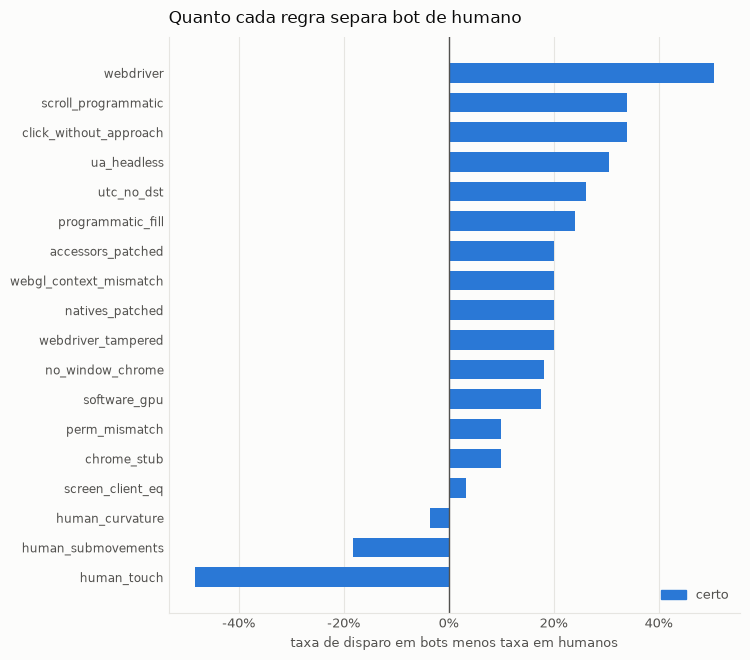

In [18]:
rules_cat = pd.DataFrame(json.loads((ROOT / "data/features/rules.json").read_text()))
# baseline_rules traz os ids que dispararam, na ordem em que a página os mostra.
disparou = df.baseline_rules.fillna("").str.split("|").apply(set)

linhas = []
for r in rules_cat.itertuples():
    hit = disparou.apply(lambda ids, rid=r.id: rid in ids)
    linhas.append({"regra": r.id, "camada": r.layer, "grupo": r.group, "peso": r.w,
                   "em humanos": float(hit[df.label == "human"].mean()),
                   "em bots": float(hit[df.label == "bot"].mean())})

audit_tbl = pd.DataFrame(linhas)
audit_tbl["separação"] = audit_tbl["em bots"] - audit_tbl["em humanos"]
# Abaixo de 2 pontos percentuais a diferença não distingue nada; o sinal dela ali
# é ruído de amostra, não direção.
audit_tbl["aponta"] = np.select(
    [audit_tbl[["em humanos", "em bots"]].max(axis=1) == 0,
     audit_tbl["separação"].abs() < 0.02,
     np.sign(audit_tbl["separação"]) == np.sign(audit_tbl["peso"])],
    ["nunca dispara", "sem efeito", "certo"], default="invertida")
audit_tbl = audit_tbl.sort_values("separação", ascending=False).reset_index(drop=True)

contagem_aponta = audit_tbl.aponta.value_counts()
print(f"{len(audit_tbl)} regras: " + ", ".join(
    f"{n} {k}" for k, n in contagem_aponta.items()))
uteis = audit_tbl[audit_tbl.aponta == "certo"].nlargest(4, "separação")
print(f"a detecção se apoia em: {', '.join(uteis.regra)}")
invertidas = audit_tbl[audit_tbl.aponta == "invertida"]
if len(invertidas):
    print(f"apontando para o lado errado: {', '.join(invertidas.regra)}")
display(audit_tbl.round(3))

# --- auditoria das regras ---------------------------------------------------
# As que nunca disparam ficam de fora: seriam barras de comprimento zero.
if len(audit_tbl):
    a = audit_tbl[audit_tbl.aponta != "nunca dispara"].sort_values("separação")
    cores = {"certo": S1, "invertida": S2, "sem efeito": S3}
    fig, ax = plt.subplots(figsize=(7.6, 0.3 * len(a) + 1.3))
    eixo(ax, "Quanto cada regra separa bot de humano", grid="x")
    ax.barh(np.arange(len(a)), a["separação"], height=0.66,
            color=[cores[v] for v in a.aponta])
    ax.axvline(0, color=INK2, lw=1)
    ax.set_yticks(np.arange(len(a)))
    ax.set_yticklabels(a.regra, fontsize=8.5)
    ax.set_xlabel("taxa de disparo em bots menos taxa em humanos", color=INK2, fontsize=9)
    ax.xaxis.set_major_formatter(pct)
    presentes = [v for v in ("certo", "invertida", "sem efeito") if (a.aponta == v).any()]
    ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=cores[v], label=v) for v in presentes],
              frameon=False, labelcolor=INK2, fontsize=9, loc="lower right")
    mostrar(fig)


## 12. O Veredito ao Longo da Visita

Todas as métricas acima descrevem a sessão inteira, gravada quando a pessoa clicou
em enviar ou quando o roteiro do bot terminou. Não é assim que a página é usada:
ela responde desde o primeiro instante e revê o veredito conforme a evidência
chega. Uma página que só acerta no fim de trinta segundos não serve para decidir
nada.

Esta seção corta os eventos de cada sessão em instantes fixos e reavalia,
reconstruindo o que a página teria respondido naquele momento, com a mesma
política de `web/src/decision.js`: as regras decidem, o modelo assume quando todas
as features comportamentais que as árvores usam existem, e artefato direto de
automação mantém a decisão nas regras.

A pontuação do modelo é fora da amostra. As árvores de cada partição veem apenas
sessões completas de outros participantes e pontuam os cortes das sessões retidas,
então nenhum corte é pontuado por um modelo que viu aquela pessoa.


1266 avaliações em 6 instantes, mais as 211 sessões completas
falso positivo contado sobre 31 sessões humanas


,instante,falso positivo,detecção,decididas pelo modelo
0,0.5s,0,0.7056,0
1,1s,0,0.7056,0
2,2s,0,0.7056,0
3,5s,0,0.8000,2
4,10s,1,0.8056,7
5,20s,1,0.9000,36
6,completa,0,0.9000,38


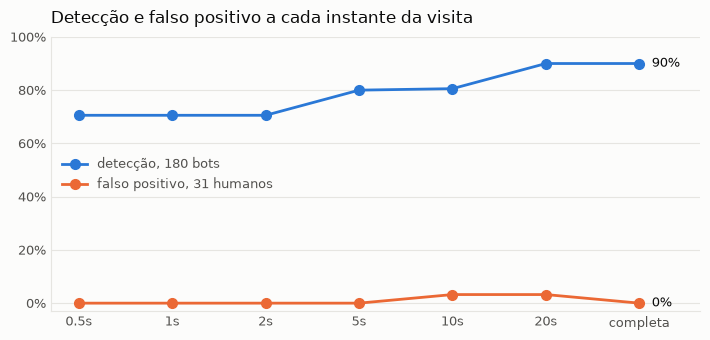

In [19]:
tempo_tbl = pd.DataFrame()
tl_path = ROOT / "data/features/timeline.csv"
if HAS_BOTH_CLASSES and tl_path.exists() and payload is not PLACEHOLDER:
    tl = pd.read_csv(tl_path, low_memory=False)
    tl = tl[tl.session_id.isin(df.session_id)].reset_index(drop=True)

    # Fora da amostra: treina em sessões completas, pontua os cortes das retidas.
    tl_model = pd.Series(np.nan, index=tl.index)
    for tr, te in StratifiedGroupKFold(n_splits=5, shuffle=True,
                                       random_state=42).split(df[feats], y, groups):
        if len(np.unique(y[tr])) < 2:
            continue
        m = make_gbdt()
        m.fit(df[feats].iloc[tr], y[tr])
        sel = tl.session_id.isin(df.session_id.iloc[te]).to_numpy()
        if sel.any():
            tl_model[sel] = m.predict_proba(tl.loc[sel, feats])[:, 1]

    # A porta e a precedência do grupo hard, iguais às de decision.js.
    exigidas_b = [f for f in usadas_tbl.feature if f.startswith("b_")]
    hard_ids = set(rules_cat.loc[rules_cat.group == "hard", "id"])

    def combinar(quadro, modelo_p):
        porta = quadro[exigidas_b].notna().all(axis=1) if exigidas_b else False
        hard = quadro.baseline_rules.fillna("").str.split("|").apply(
            lambda ids: bool(hard_ids & set(ids)))
        usa = porta & ~hard & pd.Series(modelo_p, index=quadro.index).notna()
        p = np.where(usa, pd.Series(modelo_p, index=quadro.index).fillna(0), quadro.baseline_prob)
        lim = np.where(usa, threshold, BASELINE_THRESHOLD)
        return pd.Series(p >= lim, index=quadro.index), usa

    linhas = []
    for corte, g in tl.groupby("cut_ms"):
        bot, usa = combinar(g, tl_model.loc[g.index])
        linhas.append({"instante": f"{corte / 1000:g}s", "ms": int(corte),
                       "falso positivo": int((bot & (g.label == "human")).sum()),
                       "detecção": float(bot[g.label == "bot"].mean()),
                       "decididas pelo modelo": int(usa.sum())})

    # A sessão completa fecha a curva, com a mesma predição fora da amostra do E4.
    bot_f, usa_f = combinar(df, oof)
    linhas.append({"instante": "completa", "ms": int(df.elapsed_ms.max()),
                   "falso positivo": int((bot_f & (df.label == "human")).sum()),
                   "detecção": float(bot_f[df.label == "bot"].mean()),
                   "decididas pelo modelo": int(usa_f.sum())})

    tempo_tbl = (pd.DataFrame(linhas).sort_values("ms")
                 .drop(columns="ms").reset_index(drop=True))
    n_h = int((df.label == "human").sum())
    print(f"{len(tl)} avaliações em {tl.cut_ms.nunique()} instantes, "
          f"mais as {len(df)} sessões completas")
    print(f"falso positivo contado sobre {n_h} sessões humanas")
    display(tempo_tbl.round(4))
else:
    print("indisponível: exige as duas classes, um modelo publicado e "
          "data/features/timeline.csv (ver README, seção Reproduzir a análise)")

# --- o veredito ao longo da visita -----------------------------------------
# Duas medidas, um eixo só: o falso positivo vira taxa sobre as sessões humanas,
# em vez de ganhar um segundo eixo com outra escala.
if len(tempo_tbl):
    t = tempo_tbl
    x = np.arange(len(t))
    det = t["detecção"].to_numpy()
    fp = t["falso positivo"].to_numpy() / n_h
    fig, ax = plt.subplots(figsize=(7.2, 3.5))
    eixo(ax, "Detecção e falso positivo a cada instante da visita")
    ax.plot(x, det, color=S1, lw=2, marker="o", ms=7, label=f"detecção, {int((df.label == 'bot').sum())} bots")
    ax.plot(x, fp, color=S2, lw=2, marker="o", ms=7, label=f"falso positivo, {n_h} humanos")
    for serie, cor in ((det, S1), (fp, S2)):
        ax.annotate(f"{serie[-1]:.0%}", (x[-1], serie[-1]), textcoords="offset points",
                    xytext=(9, 0), color=INK, fontsize=9, va="center")
    ax.set_xticks(x)
    ax.set_xticklabels(t["instante"])
    ax.set_xlim(-0.3, len(t) - 0.35)
    ax.set_ylim(-0.03, 1.0)
    ax.yaxis.set_major_formatter(pct)
    ax.legend(frameon=False, labelcolor=INK2, fontsize=9, loc="center left")
    mostrar(fig)


## 13. Curva de Aprendizado por Participante

O modelo foi treinado com 13 pessoas, o que é pouco, e a decisão de publicá-lo
baixou o mínimo de 30 participantes para 11. Essa decisão está registrada, mas era
julgamento, não medida. Esta seção mede: o desempenho ainda sobe quando se
acrescenta gente, ou já estabilizou?

O protocolo separa por participante. Um terço das pessoas fica de fora em cada
sorteio, junto com um terço dos bots, e o treino recebe as primeiras `k` pessoas
restantes. Se a curva ainda estiver subindo no último ponto, 13 pessoas não bastam
e o número medido aqui é otimista em relação ao que uma décima quarta pessoa
encontraria.


4 pessoas retidas por sorteio, 9 disponíveis para o treino
da metade da curva ao último ponto, a AUC mediana move +0.0000; o máximo é atingido com 5 pessoas


,pessoas no treino,sorteios,sessões humanas,auc_mediana,auc_p10,tpr_mediano
0,1,12,2.0,0.9002,0.8186,0.7500
1,2,12,4.0,0.9858,0.9057,0.9250
2,3,12,6.0,0.9983,0.9934,0.9833
3,4,12,9.5,0.9992,0.9000,0.9917
4,5,12,12.0,1.0000,0.9472,1.0000
5,6,12,14.0,1.0000,0.9953,1.0000
6,7,12,16.5,1.0000,0.9950,1.0000
7,8,12,19.0,1.0000,0.9950,1.0000
8,9,12,21.0,1.0000,0.9968,1.0000


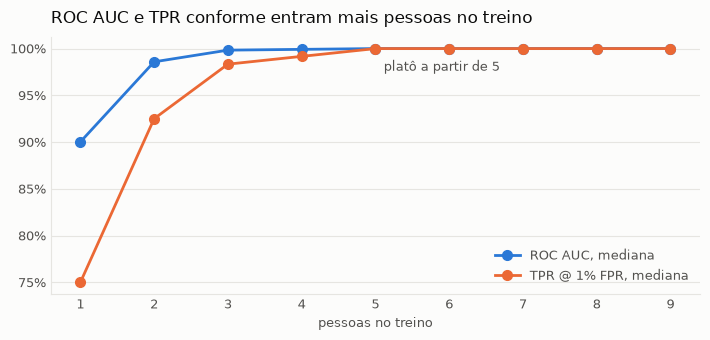

In [20]:
curva_tbl = pd.DataFrame()
partes = np.asarray(sorted(df.loc[df.label == "human", "participant"].unique()), dtype=object)
if HAS_BOTH_CLASSES and len(partes) >= 6:
    rng = np.random.default_rng(20260919)
    idx_bot = df.index[df.label == "bot"].to_numpy()
    n_teste = max(2, len(partes) // 3)
    linhas = []
    for _ in range(12):
        perm = rng.permutation(partes)
        p_teste, p_treino = perm[:n_teste], perm[n_teste:]
        b_perm = rng.permutation(idx_bot)
        corte = int(len(b_perm) * 2 / 3)
        b_treino, b_teste = b_perm[:corte], b_perm[corte:]
        i_teste = np.concatenate(
            [df.index[(df.label == "human") & df.participant.isin(p_teste)].to_numpy(), b_teste])
        y_teste = (df.loc[i_teste, "label"] == "bot").astype(int).to_numpy()
        for k in range(1, len(p_treino) + 1):
            i_treino = np.concatenate(
                [df.index[(df.label == "human") & df.participant.isin(p_treino[:k])].to_numpy(),
                 b_treino])
            m = make_gbdt()
            m.fit(df.loc[i_treino, feats], (df.loc[i_treino, "label"] == "bot").astype(int))
            p = m.predict_proba(df.loc[i_teste, feats])[:, 1]
            linhas.append({"pessoas no treino": k,
                           "sessões humanas no treino": int(
                               ((df.label == "human") & df.participant.isin(p_treino[:k])).sum()),
                           "roc_auc": roc_auc_score(y_teste, p),
                           "tpr@1%fpr": tpr_at_fpr(y_teste, p)})

    curva_tbl = (pd.DataFrame(linhas).groupby("pessoas no treino")
                 .agg(sorteios=("roc_auc", "size"),
                      sessoes=("sessões humanas no treino", "median"),
                      auc_mediana=("roc_auc", "median"),
                      auc_p10=("roc_auc", lambda s: s.quantile(0.10)),
                      tpr_mediano=("tpr@1%fpr", "median"))
                 .reset_index()
                 .rename(columns={"sessoes": "sessões humanas"}))
    # Contagem é contagem: o relatório fica com 12 e não com 12.0.
    for col in ("pessoas no treino", "sorteios"):
        curva_tbl[col] = curva_tbl[col].astype(int)
    # O que decide a leitura: a curva ainda sobe na segunda metade, ou já é platô?
    ganho = float(curva_tbl.auc_mediana.iloc[-1] - curva_tbl.auc_mediana.iloc[len(curva_tbl) // 2])
    satura_em = int(curva_tbl.loc[curva_tbl.auc_mediana >= curva_tbl.auc_mediana.max() - 1e-9,
                                  "pessoas no treino"].min())
    print(f"{n_teste} pessoas retidas por sorteio, {len(partes) - n_teste} disponíveis para o treino")
    print(f"da metade da curva ao último ponto, a AUC mediana move {ganho:+.4f}; "
          f"o máximo é atingido com {satura_em} pessoas")
    display(curva_tbl.round(4))
else:
    print(f"indisponível: {len(partes)} participantes humanos, mínimo 6")

# --- curva de aprendizado ---------------------------------------------------
if len(curva_tbl):
    k = curva_tbl["pessoas no treino"]
    fig, ax = plt.subplots(figsize=(7.2, 3.5))
    eixo(ax, "ROC AUC e TPR conforme entram mais pessoas no treino")
    # Sem faixa de percentil: com 12 sorteios o p10 salta de um k para o outro e a
    # área desenha uma cunha que parece dado, não dispersão. O p10 fica na tabela.
    ax.plot(k, curva_tbl.auc_mediana, color=S1, lw=2, marker="o", ms=7, label="ROC AUC, mediana")
    ax.plot(k, curva_tbl.tpr_mediano, color=S2, lw=2, marker="o", ms=7, label="TPR @ 1% FPR, mediana")
    ax.annotate(f"platô a partir de {satura_em}", (satura_em, curva_tbl.auc_mediana.max()),
                textcoords="offset points", xytext=(6, -16), color=INK2, fontsize=9)
    ax.set_xticks(k)
    ax.set_xlabel("pessoas no treino", color=INK2, fontsize=9)
    ax.yaxis.set_major_formatter(pct)
    ax.legend(frameon=False, labelcolor=INK2, fontsize=9, loc="lower right")
    mostrar(fig)


## 14. Geração do Relatório de Resultados

Escreve `docs/03-resultados.md` a partir das tabelas acima, para que o documento


In [21]:
def fmt(frame: pd.DataFrame) -> str:
    f = frame.round(4)
    head = "| " + " | ".join(str(c) for c in f.columns) + " |"
    sep = "|" + "---|" * len(f.columns)
    # itertuples preserva o tipo de cada coluna; .values promoveria uma tabela que
    # mistura contagem e taxa a float, e a contagem sairia como "12.0".
    body = ["| " + " | ".join(str(v) for v in row) + " |"
            for row in f.itertuples(index=False, name=None)]
    return "\n".join([head, sep, *body])


out = ["# 3. Resultados\n",
       "> Gerado por `analysis/notebooks/bot_detection_analysis.ipynb`. Não editar à mão.\n",
       "## Composição do Dataset\n",
       f"{len(df)} sessões, {df.participant.nunique()} participantes/grupos, "
       f"{len(feats)} features não constantes.\n",
       fmt(df.groupby(['config', 'journey'], dropna=False).size()
           .reset_index(name='n')), ""]

out += ["## Detecção do Motor de Regras\n",
        "Motor de regras avaliado separadamente, nas sessões completas e no seu limiar de operação. Para sessões `bot` a coluna "
        "`taxa` é detecção; para `human`, falso positivo. As regras foram escritas "
        "olhando estas mesmas sessões automatizadas, então a taxa dos bots descreve o "
        "ajuste, e não uma medida fora da amostra.\n",
        fmt(baseline_tbl), ""]

if HAS_BOTH_CLASSES:
    if len(ks):
        out += ["## Testes Distributivos\n",
                f"Kolmogorov-Smirnov por feature com correção de Benjamini-Hochberg a 5%: "
                f"**{int(ks.significativo.sum())} de {len(ks)}** features separam as classes "
                f"com significância.\n",
                "As 15 mais discriminantes:\n",
                fmt(ks.sort_values('ks', ascending=False)
                    .head(15)[['feature', 'camada', 'ks', 'p']]), ""]

    out += ["## E4: Regras contra Modelos Treinados\n",
            f"Intervalos de 95% por bootstrap agrupado por participante. Com {n_human} "
            f"sessões humanas, o menor FPR acima de zero é {1 / n_human:.1%}.\n",
            fmt(pd.DataFrame(results).T[['roc_auc', 'auc_lo', 'auc_hi', 'pr_auc',
                                         'tpr@1%fpr', 'tpr_lo', 'tpr_hi', 'f1']]
                .reset_index().rename(columns={'index': 'modelo'})), "",
            "### Contribuição por Camada de Sinal\n", fmt(layer_tbl), "",
            "## E1: Ablação dos Artefatos Óbvios\n",
            "Quanto sinal sobra quando o atacante apaga todo rastro direto de automação.\n",
            fmt(ablation_tbl), ""]

    if len(loto_tbl):
        out += ["## E2: Generalização para Ferramenta Não Vista\n", fmt(loto_tbl), ""]
    if len(strat_tbl):
        out += ["## E3: Desempenho por Sofisticação\n", fmt(strat_tbl), ""]
    if oneclass:
        out += ["## E5: Detecção de Novidade sobre a Classe Humana\n",
                "Treinado só com pessoas, sem ver nenhum bot. Sessão sem interação não tem "
                "comportamento a julgar: a imputação pela mediana a faz parecer a pessoa média, "
                "então o experimento aparece com e sem essas sessões.\n",
                f"Mediana de {oneclass['n_divisoes']} divisões treino/teste por participante, "
                f"com a faixa entre parênteses: com pouco mais de dez pessoas, quem cai no "
                f"treino move o resultado em várias décimas.\n",
                f"- Só com evidência comportamental, teste com {oneclass['n_human']} humanas e "
                f"{oneclass['n_bot']} bots: ROC AUC **{oneclass['roc_auc']:.3f}** "
                f"({oneclass['auc_lo']:.3f} a {oneclass['auc_hi']:.3f}), TPR @ 1% FPR "
                f"**{oneclass['tpr@1%fpr']:.3f}** ({oneclass['tpr_lo']:.3f} a {oneclass['tpr_hi']:.3f})"]
        if oneclass_todos:
            out += [f"- Todas as sessões, teste com {oneclass_todos['n_human']} humanas e "
                    f"{oneclass_todos['n_bot']} bots: ROC AUC "
                    f"**{oneclass_todos['roc_auc']:.3f}** ({oneclass_todos['auc_lo']:.3f} a "
                    f"{oneclass_todos['auc_hi']:.3f}), TPR @ 1% FPR "
                    f"**{oneclass_todos['tpr@1%fpr']:.3f}** ({oneclass_todos['tpr_lo']:.3f} a "
                    f"{oneclass_todos['tpr_hi']:.3f})"]
        out += [""]
else:
    out += ["## Experimentos Supervisionados\n",
            f"> O dataset contém apenas a classe `{df.label.iloc[0]}`. Os experimentos "
            "E1 a E5 exigem as duas classes e serão executados após a coleta de "
            "sessões humanas.\n"]

if len(audit_tbl):
    mudas = int((audit_tbl.aponta == "nunca dispara").sum())
    inv = audit_tbl[audit_tbl.aponta == "invertida"]
    out += ["## Auditoria do Motor de Regras\n",
            f"Taxa de disparo de cada uma das {len(audit_tbl)} regras, por classe, nas "
            f"sessões completas. Peso positivo acusa automação, negativo defende o "
            f"visitante; `aponta` compara o sinal da separação com o sinal do peso.\n",
            f"{mudas} regras não disparam em nenhuma sessão deste conjunto: são cobertura "
            f"para adversários que a matriz não gera, e não contribuem com a detecção medida "
            f"aqui.\n"]
    if len(inv):
        out += [f"{len(inv)} apontam para o lado errado nestes dados "
                f"({', '.join('`' + r + '`' for r in inv.regra)}). O viés heurístico absorve "
                f"o efeito no veredito, mas o texto que a página mostra para essas regras "
                f"descreve o contrário do que os dados dizem.\n"]
    out += [fmt(audit_tbl), ""]

if len(tempo_tbl):
    out += ["## O Veredito ao Longo da Visita\n",
            "Eventos cortados em instantes fixos e reavaliados com a política de "
            "`web/src/decision.js`. A pontuação do modelo é fora da amostra: as árvores de "
            "cada partição veem só sessões completas de outros participantes.\n",
            "Esta é a tabela que as métricas de sessão completa não mostram. O falso "
            "positivo da sessão completa é zero, mas durante a visita existem falsos "
            "positivos transitórios, enquanto a evidência comportamental ainda não chegou.\n",
            fmt(tempo_tbl), ""]

if len(curva_tbl):
    out += ["## Curva de Aprendizado por Participante\n",
            f"AUC em função de quantas pessoas entram no treino, separando por participante: "
            f"um terço das pessoas e um terço dos bots ficam de fora em cada sorteio. "
            f"Mediana de {int(curva_tbl.sorteios.iloc[0])} sorteios por ponto.\n",
            (f"Da metade da curva ao último ponto a AUC mediana move {ganho:+.4f}, e o máximo "
             f"já aparece com {satura_em} pessoas: a curva é platô, então o que limita o "
             f"modelo não é o número de participantes.\n"
             if ganho < 0.01 else
             f"Da metade da curva ao último ponto a AUC mediana ainda sobe {ganho:+.4f}: com "
             f"{len(partes)} pessoas o modelo ainda não saturou, e o número medido aqui é "
             f"otimista em relação ao que uma pessoa a mais encontraria.\n"),
            fmt(curva_tbl), ""]

out += ["## Modelo na Página\n", f"Decisão desta execução: {model_decision}.\n"]

if len(usadas_tbl):
    out += [f"O modelo exportado decide com {len(usadas_tbl)} features, de "
            f"{len(payload['feature_names'])} disponíveis. A página só o usa quando as "
            f"comportamentais entre elas existem na sessão; até lá, decidem as regras.\n",
            fmt(usadas_tbl[['feature', 'camada', 'nós']]), ""]

out += ["A página usa regras no início e passa ao modelo quando as features comportamentais usadas pelas árvores estão disponíveis. Sinais diretos de automação mantêm a decisão das regras. As métricas de cada motor avaliam regras e modelos separadamente em sessões completas; a seção sobre o veredito ao longo da visita mede a transição. Veja a [política de decisão](02-metodologia.md#27-como-o-veredito-é-decidido-e-por-que-humanos-vinham-dando-bot).\n"]

dest = ROOT / "docs/03-resultados.md"
dest.write_text("\n".join(out), encoding="utf-8")


14980